# Set up

In [1]:
import kagglehub
# kagglehub.login()

In [2]:
k_67_object_detection_path = kagglehub.competition_download('2425-ii-ait-3002-2-object-detection')
print('Data source import complete.')

Data source import complete.


# Import Libs

#  Mô tả Bộ Dữ Liệu

Bộ dữ liệu được tổ chức thành hai thư mục chính: `Train` và `Test`.

### Thư Mục Train
Gồm 2 thư mục con:

- `images/`: Chứa các tệp hình ảnh định dạng `.jpg`.
- `labels/`: Chứa các tệp nhãn tương ứng với mỗi ảnh, bao gồm:
  - **Nhãn phân loại**:
    - Apple: `0`
    - Banana: `1`
    - Grapes: `2`
    - Orange: `3`
    - Pineapple: `4`
    - Watermelon: `5`
  - **Tọa độ bounding box** (thường ở định dạng: `x_center y_center width height`, được chuẩn hóa)

### Thư Mục Test

- Chứa các hình ảnh **không có nhãn**
- Được sử dụng cho:
  - **Kiểm tra công khai (Public Test)**: Kết quả hiển thị trên bảng xếp hạng công khai sau khi nộp bài
  - **Kiểm tra riêng tư (Private Test)**: Dùng để đánh giá cuối cùng và xếp hạng trên bảng xếp hạng riêng tư

> **Lưu ý**: Người tham gia phải chọn một lần nộp trước đó để được đánh giá trên tập kiểm tra riêng tư. Kết quả cuối cùng sẽ dựa trên bài kiểm tra này và được công bố sau khi cuộc thi kết thúc.

###  Định Dạng Hình Ảnh

- Tất cả hình ảnh trong bộ dữ liệu đều có định dạng **`.jpg`**.


### Huấn Luyện & Đánh Giá

- Thư mục `Train` và `Val`: Chứa dữ liệu đã gán nhãn, dùng để huấn luyện và xác thực mô hình.
- Thư mục `Test`: Không có nhãn, được sử dụng để đánh giá mô hình trong giai đoạn cuối cuộc thi.



In [3]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.10.19
    Uninstalling nvidia-curand-cu12-10.3.1

In [4]:
import os
import random
from glob import glob

import numpy as np
import pandas as pd
import cv2
import shutil
import yaml
import json
import torch
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
from ultralytics import YOLO
from collections import Counter
from IPython.display import Image as IPImage, display

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Data Processing

In [5]:
# Thư mục train/val
DATASET_ROOT_DIR = '/kaggle/working/obj-detection'
PREDICT_SAVE_DIR = '/kaggle/working/test_predictions'

ORIG_TRAIN_IMG_DIR = '/kaggle/input/2425-ii-ait-3002-2-object-detection/Dataset/Train/images'
ORIG_TRAIN_LBL_DIR = '/kaggle/input/2425-ii-ait-3002-2-object-detection/Dataset/Train/labels'
TEST_IMG_PATH = '/kaggle/input/2425-ii-ait-3002-2-object-detection/Dataset/Test/images'

TRAIN_IMG_PATH = '/kaggle/working/obj-detection/train/images'
TRAIN_LBL_PATH = '/kaggle/working/obj-detection/train/labels'
VAL_IMG_PATH = '/kaggle/working/obj-detection/val/images'
VAL_LBL_PATH = '/kaggle/working/obj-detection/val/labels'

CLASS_NAMES = ['Apple', 'Grapes', 'Pineapple', 'Orange', 'Banana', 'Watermelon']
NUM_CLASSES = len(CLASS_NAMES)
YOLO_ID_TO_ORIGINAL_ID = {i: i for i in range(6)}
DATA_YAML_PATH = ('/kaggle/working/fruit_data.yaml')

##  Convert absolute coordinates label to YOLO format 
### ([class_id] [x_min] [y_min] [x_max] [y_max] => [class_id] [x_center] [y_center] [width] [height])

In [6]:
# === Utils ===
def create_directories(*dirs):
    """Create directories if they do not exist."""
    for d in dirs:
        os.makedirs(d, exist_ok=True)
        print(f"[INFO] Created directory: {d}")

def get_image_dimensions(image_path):
    """Read image and return its height and width."""
    img = cv2.imread(image_path)
    if img is None:
        print(f"[WARN] Cannot read image: {image_path}")
        return None, None
    h, w = img.shape[:2]
    if h == 0 or w == 0:
        print(f"[WARN] Image has zero dimension: {image_path}")
        return None, None
    return h, w

def normalize_box_coords(x_min, y_min, x_max, y_max, img_w, img_h):
    """Normalize bounding box coordinates to [0,1]"""
    box_w = x_max - x_min
    box_h = y_max - y_min
    x_center = x_min + box_w / 2
    y_center = y_min + box_h / 2

    clamp = lambda v, dim: max(0.0, min(1.0, v / dim))
    return (
        clamp(x_center, img_w),
        clamp(y_center, img_h),
        clamp(box_w, img_w),
        clamp(box_h, img_h)
    )

def convert_and_normalize_label(orig_label_path, new_label_path, image_path):
    """Convert labels from [x_min, y_min, x_max, y_max] to YOLO format and normalize."""
    img_h, img_w = get_image_dimensions(image_path)
    if img_h is None or img_w is None:
        return False

    lines = []
    try:
        with open(orig_label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                try:
                    class_id = int(parts[0])
                    x_min, y_min, x_max, y_max = map(float, parts[1:])
                except ValueError:
                    continue

                if not (0 <= class_id < NUM_CLASSES):
                    continue

                if x_max <= x_min or y_max <= y_min:
                    continue

                x_c, y_c, w_n, h_n = normalize_box_coords(x_min, y_min, x_max, y_max, img_w, img_h)
                lines.append(f"{class_id} {x_c:.6f} {y_c:.6f} {w_n:.6f} {h_n:.6f}\n")

    except Exception as e:
        print(f"[WARN] Error reading label file {orig_label_path}: {e}")
        open(new_label_path, 'w').close()
        return False

    with open(new_label_path, 'w') as f:
        f.writelines(lines)
    return True

## Split train/valid

In [7]:
# Main Processing Function 
def process_and_copy_files(
    stems,
    dest_img_dir, dest_lbl_dir,
    img_stem_map, lbl_stem_map,
    src_img_dir, src_lbl_dir,
    is_train=True
):
    """Process images and labels: copy and normalize labels to YOLO format."""
    mode = "Train" if is_train else "Validation"
    print(f"[INFO] Processing files for {mode} set...")

    img_count, lbl_count = 0, 0

    for stem in tqdm(stems, desc=f"Processing {mode}"):
        img_file = img_stem_map.get(stem)
        lbl_file = lbl_stem_map.get(stem)

        if not img_file or not lbl_file:
            print(f"[WARN] Missing file for stem {stem}, skipping.")
            continue

        src_img = os.path.join(src_img_dir, img_file)
        src_lbl = os.path.join(src_lbl_dir, lbl_file)
        dst_img = os.path.join(dest_img_dir, img_file)
        dst_lbl = os.path.join(dest_lbl_dir, f"{stem}.txt")

        if not os.path.exists(src_img) or not os.path.exists(src_lbl):
            print(f"[WARN] Missing image or label file for {stem}, skipping.")
            continue

        shutil.copy(src_img, dst_img)
        img_count += 1

        if convert_and_normalize_label(src_lbl, dst_lbl, src_img):
            lbl_count += 1

    print(f"[DONE] {mode}: {img_count} images copied, {lbl_count} labels processed.")

In [8]:
def prepare_data():
    print("Chuẩn bị dữ liệu...")
    create_directories(DATASET_ROOT_DIR, TRAIN_IMG_PATH, TRAIN_LBL_PATH, VAL_IMG_PATH, VAL_LBL_PATH, PREDICT_SAVE_DIR)

    all_orig_image_files = sorted([f for f in os.listdir(ORIG_TRAIN_IMG_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    all_orig_label_files = sorted([f for f in os.listdir(ORIG_TRAIN_LBL_DIR) if f.lower().endswith('.txt')])

    image_stem_to_filename = {os.path.splitext(f)[0]: f for f in all_orig_image_files}
    label_stem_to_filename = {os.path.splitext(f)[0]: f for f in all_orig_label_files}

    common_stems = sorted(set(image_stem_to_filename) & set(label_stem_to_filename))

    random.seed(42)
    random.shuffle(common_stems)
    split_idx = int(len(common_stems) * (1 - VAL_SPLIT_RATIO))
    train_stems = common_stems[:split_idx]
    val_stems = common_stems[split_idx:]

    process_and_copy_files(train_stems, TRAIN_IMG_PATH, TRAIN_LBL_PATH, image_stem_to_filename, label_stem_to_filename, ORIG_TRAIN_IMG_DIR, ORIG_TRAIN_LBL_DIR, True)
    process_and_copy_files(val_stems, VAL_IMG_PATH, VAL_LBL_PATH, image_stem_to_filename, label_stem_to_filename, ORIG_TRAIN_IMG_DIR, ORIG_TRAIN_LBL_DIR, False)

VAL_SPLIT_RATIO = 0.1
prepare_data()

Chuẩn bị dữ liệu...
[INFO] Created directory: /kaggle/working/obj-detection
[INFO] Created directory: /kaggle/working/obj-detection/train/images
[INFO] Created directory: /kaggle/working/obj-detection/train/labels
[INFO] Created directory: /kaggle/working/obj-detection/val/images
[INFO] Created directory: /kaggle/working/obj-detection/val/labels
[INFO] Created directory: /kaggle/working/test_predictions
[INFO] Processing files for Train set...


Processing Train:   0%|          | 0/6867 [00:00<?, ?it/s]

[DONE] Train: 6867 images copied, 6867 labels processed.
[INFO] Processing files for Validation set...


Processing Validation:   0%|          | 0/764 [00:00<?, ?it/s]

[DONE] Validation: 764 images copied, 764 labels processed.


## Data analyst

In [9]:
### Số lượng ảnh và nhãn theo tập train/val/test
def count_files(img_dir, lbl_dir):
    img_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg') or f.endswith('.png')]
    lbl_files = [f for f in os.listdir(lbl_dir) if f.endswith('.txt')]
    return len(img_files), len(lbl_files)

train_imgs, train_lbls = count_files(TRAIN_IMG_PATH, TRAIN_LBL_PATH)
val_imgs, val_lbls = count_files(VAL_IMG_PATH, VAL_LBL_PATH)
test_imgs = len([f for f in os.listdir(TEST_IMG_PATH) if f.endswith('.jpg') or f.endswith('.png')])

print("Train set: ", train_imgs, "images,", train_lbls, "labels")
print("Val set:   ", val_imgs, "images,", val_lbls, "labels")
print("Test set:  ", test_imgs, "images")

Train set:  6867 images, 6867 labels
Val set:    764 images, 764 labels
Test set:   848 images


In [10]:
### Phân phối số lượng object theo class (class frequency)
def count_objects_in_labels(lbl_dir):
    class_counter = Counter()
    for file in os.listdir(lbl_dir):
        if not file.endswith('.txt'):
            continue
        with open(os.path.join(lbl_dir, file)) as f:
            for line in f:
                cls_id = int(line.strip().split()[0])
                class_counter[cls_id] += 1
    return class_counter

train_class_count = count_objects_in_labels(TRAIN_LBL_PATH)
val_class_count = count_objects_in_labels(VAL_LBL_PATH)

print("Train class distribution:")
for i in range(NUM_CLASSES):
    print(f"{CLASS_NAMES[i]}: {train_class_count[i]}")

print("\nVal class distribution:")
for i in range(NUM_CLASSES):
    print(f"{CLASS_NAMES[i]}: {val_class_count[i]}")

Train class distribution:
Apple: 5765
Grapes: 2903
Pineapple: 5679
Orange: 12424
Banana: 1264
Watermelon: 1559

Val class distribution:
Apple: 534
Grapes: 263
Pineapple: 810
Orange: 1300
Banana: 155
Watermelon: 161


In [11]:
### Thống kê kích thước bounding box (rộng, cao trung bình)
def bbox_stats(lbl_dir):
    widths, heights = [], []
    for file in os.listdir(lbl_dir):
        if not file.endswith('.txt'):
            continue
        with open(os.path.join(lbl_dir, file)) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5: continue
                _, x_c, y_c, w, h = map(float, parts)
                widths.append(w)
                heights.append(h)
    return sum(widths)/len(widths), sum(heights)/len(heights)

avg_w, avg_h = bbox_stats(TRAIN_LBL_PATH)
print(f"Average bbox width: {avg_w:.4f}, height: {avg_h:.4f}")

Average bbox width: 0.2108, height: 0.2438


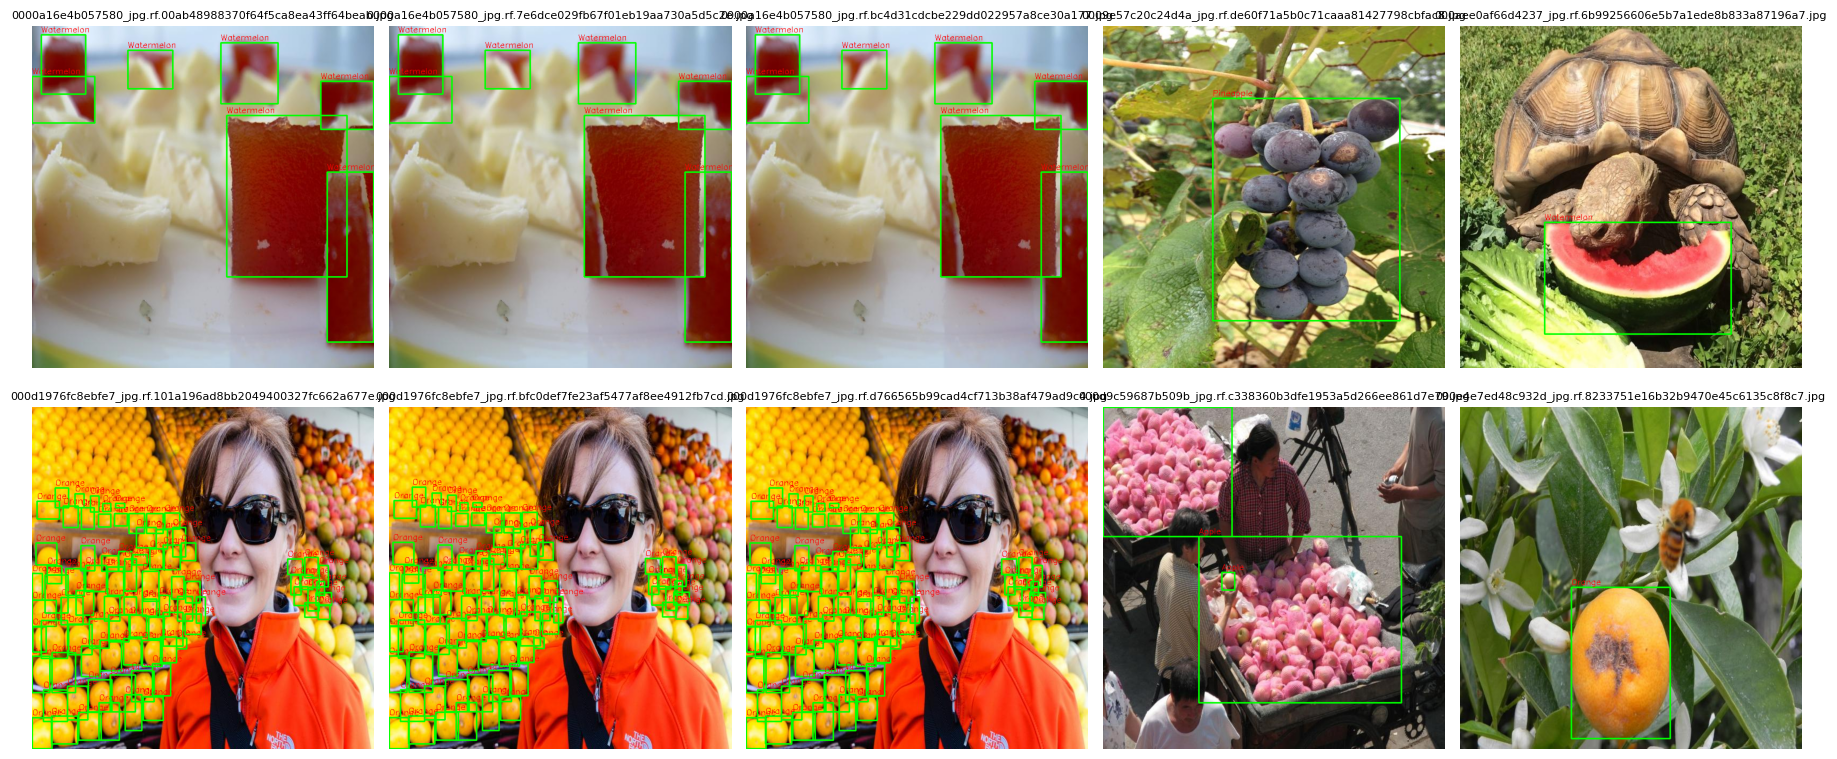

In [12]:
### Visualize ảnh và bbox để sanity check
def load_image_with_bbox(img_path, lbl_path):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Cannot read image: {img_path}")
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    try:
        with open(lbl_path) as f:
            for line in f:
                cls_id, x, y, bw, bh = map(float, line.strip().split())
                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, CLASS_NAMES[int(cls_id)], (x1, y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    except Exception as e:
        print(f"Error reading label {lbl_path}: {e}")
        return None
    return img

# Show first 10 images 
img_files = sorted([f for f in os.listdir(TRAIN_IMG_PATH) if f.endswith(('.jpg', '.png'))])[:10]

plt.figure(figsize=(18, 8))
for idx, img_file in enumerate(img_files):
    label_file = os.path.splitext(img_file)[0] + '.txt'
    img_path = os.path.join(TRAIN_IMG_PATH, img_file)
    lbl_path = os.path.join(TRAIN_LBL_PATH, label_file)

    img = load_image_with_bbox(img_path, lbl_path)
    if img is not None:
        plt.subplot(2, 5, idx + 1)
        plt.imshow(img)
        plt.title(img_file, fontsize=8)
        plt.axis('off')

plt.tight_layout()
plt.show()

## Create yaml

In [13]:
def create_yolo_yaml():
    yaml_content = {
        'train': os.path.abspath(TRAIN_IMG_PATH),
        'val': os.path.abspath(VAL_IMG_PATH),
        'nc': NUM_CLASSES,
        'names': CLASS_NAMES
    }

    with open(DATA_YAML_PATH, 'w') as f:
        yaml.dump(yaml_content, f, sort_keys=False)
    print(f"Tạo file YAML tại: {DATA_YAML_PATH}")

create_yolo_yaml()

Tạo file YAML tại: /kaggle/working/fruit_data.yaml


# Train and Evaluate

In [14]:
def train_model():
    model = YOLO(MODEL_NAME)
    print(f"[INFO] Training model: {MODEL_NAME}")

    model.train(
        data=DATA_YAML_PATH,
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        project=PROJECT_NAME,
        name=RUN_NAME,
        device=DEVICE,
        patience=PATIENCE,
        workers=WORKERS,
        exist_ok=True,

        optimizer=OPTIMIZER,
        lr0=LR0,
        lrf=LRF,
        cos_lr=COS_LR,
        weight_decay=WEIGHT_DECAY,
        augment=AUGMENT,
        pretrained=PRETRAINED,
    )

    print(" Training complete!")
    return model

In [15]:
def evaluate_model(model):
    """Evaluate the model on the test set and display metrics and visuals."""
    
    print("\nEvaluating model on test set (mAP@0.5)...")
    metrics = model.val(
        data=DATA_YAML_PATH,
        imgsz=IMG_SIZE,
        split='val',
        conf=0.25,
        iou=0.45,
        project=PROJECT_NAME,
        name=f"{RUN_NAME}_eval",
        exist_ok=True
    )

    # Display metrics
    print("\n--- Evaluation Results ---")
    print(f"mAP@0.5       : {metrics.box.map50:.4f}")
    print(f"mAP@0.5:0.95  : {metrics.box.map:.4f}")

    precision = np.mean(metrics.box.p) if isinstance(metrics.box.p, (np.ndarray, list)) else metrics.box.p
    recall = np.mean(metrics.box.r) if isinstance(metrics.box.r, (np.ndarray, list)) else metrics.box.r

    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")

    # Paths
    train_results_dir = os.path.join(PROJECT_NAME, RUN_NAME)
    eval_results_dir = os.path.join(PROJECT_NAME, f"{RUN_NAME}_eval")

    # Display result images
    def show_image_if_exists(filepath, title=None, width=800):
        if os.path.exists(filepath):
            if title: print(title)
            display(IPImage(filename=filepath, width=width))
        else:
            print(f"{os.path.basename(filepath)} not found.")

    print("\nTraining results (optional):")
    show_image_if_exists(os.path.join(train_results_dir, 'results.png'), "Training Metrics", 800)
    show_image_if_exists(os.path.join(eval_results_dir, 'confusion_matrix.png'), "Confusion Matrix", 600)

    # Show sample predictions
    pred_images = sorted(glob(os.path.join(eval_results_dir, 'val_batch*_pred.jpg')))
    if pred_images:
        print("\nSample test predictions:")
        for i, img_file in enumerate(pred_images[:5]):
            print(f"Test Batch {i + 1}")
            display(IPImage(filename=img_file, width=600))
    else:
        print("No prediction images found (val_batch*_pred.jpg).")

    # Show final results table
    results_csv = os.path.join(train_results_dir, 'results.csv')
    if os.path.exists(results_csv):
        print("\nTraining metrics summary:")
        df = pd.read_csv(results_csv)
        df.columns = df.columns.str.strip()  
        print(df[['epoch', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']].tail())
    else:
        print("results.csv not found.")

# Predict and submission

In [16]:
def predict_and_submission(trained_model):
    """
    Run inference on the test set and generate a submission.csv file.
    """
    print("\n[Step 7-8] Running prediction on test set and generating submission.csv...")
    print(f"Predicting on test images in: {TEST_IMG_PATH}")

    predict_dir = os.path.join(PREDICT_SAVE_DIR, RUN_NAME)
    if os.path.exists(predict_dir):
        print(f"Removing old prediction directory: {predict_dir}")
        shutil.rmtree(predict_dir)

    results = trained_model.predict(
        source=TEST_IMG_PATH,
        imgsz=IMG_SIZE,
        conf=0,
        iou=0.6,
        augment=True,
        save=False,
        stream=True, 
        batch=BATCH_SIZE,
        device="0",
        verbose=False,
    )

    image_predictions_map = {}

    all_test_images = sorted(glob(os.path.join(TEST_IMG_PATH, '*.jpg')))
    all_test_image_names = [os.path.basename(p) for p in all_test_images]

    for img_name, result in zip(all_test_image_names, results):
        image_stem = img_name.replace('.jpg', '')
        img_path = os.path.join(TEST_IMG_PATH, img_name)
        img_h, img_w = get_image_dimensions(img_path)

        if img_h is None or img_w is None:
            print(f"Skipping image {img_name} due to unreadable dimensions.")
            continue

        boxes = []
        if result.boxes is not None and result.boxes.xyxy is not None:
            box_array = result.boxes.xyxy.cpu().numpy() 
            conf_array = result.boxes.conf.cpu().numpy() 
            class_array = result.boxes.cls.cpu().numpy()  

            for (x_min, y_min, x_max, y_max), conf, class_id in zip(box_array, conf_array, class_array):
                x_min = max(0.0, x_min)
                y_min = max(0.0, y_min)
                x_max = min(float(img_w), x_max)
                y_max = min(float(img_h), y_max)

                if x_max > x_min and y_max > y_min:
                    original_id = YOLO_ID_TO_ORIGINAL_ID.get(int(class_id), int(class_id))
                    boxes.append({
                        "x_min": float(x_min),
                        "y_min": float(y_min),
                        "x_max": float(x_max),
                        "y_max": float(y_max),
                        "class": int(original_id),
                        "confidence": float(conf)
                    })


        image_predictions_map[image_stem] = boxes

    submission_rows = []
    for img_stem in all_test_image_names:
        stem = img_stem.replace('.jpg', '')
        submission_rows.append({
            "image_id": stem,
            "bounding_boxes": json.dumps(image_predictions_map.get(stem, []))
        })

    submission_df = pd.DataFrame(submission_rows)
    submission_path = ('/kaggle/working/submission.csv')
    submission_df.to_csv(submission_path, index=False)

    print(f"\nSubmission saved to: {submission_path}")
    print(f"Total entries in submission: {len(submission_df)}")
    print("\nFirst 5 rows of submission.csv:")
    print(submission_df.head())

# YOLOv8 basic

###  Mô hình YOLOv8s

Trong số các mô hình phát hiện đối tượng hiện đại, **YOLOv8 (You Only Look Once version 8)** là một lựa chọn tối ưu nhờ khả năng **cân bằng giữa tốc độ, độ chính xác và khả năng triển khai thực tế**.

Phiên bản **YOLOv8s (Small)** được lựa chọn ở bước đầu tiên vì:

-  Mô hình nhẹ, tốc độ huấn luyện nhanh.
-  Yêu cầu tài nguyên thấp, phù hợp khi huấn luyện trên GPU phổ thông.
-  Thích hợp để thử nghiệm ban đầu và tinh chỉnh trước khi chuyển sang mô hình lớn hơn (YOLOv8m, YOLOv8l).

---

### Tham số huấn luyện

| Tham số            | Giá trị         | Giải thích                                                                 |
|--------------------|------------------|---------------------------------------------------------------------------|
| `EPOCHS`           | `50`            | Số vòng lặp toàn bộ tập dữ liệu.        |
| `BATCH_SIZE`       | `32`             | Kích thước batch phù hợp với GPU tầm trung, cân bằng giữa hiệu suất và độ ổn định. |
| `WORKERS`          | `4`              | Số luồng đọc dữ liệu song song, tăng tốc độ load dữ liệu.                |
| `DEVICE`           | `'0,1' if torch.cuda.is_available() else 'cpu'` | Sử dụng 2 GPU trên kaggle |
| `MODEL_NAME`       | `'yolov8s'`       | Chọn mô hình YOLOv8 phiên bản nhỏ, phù hợp với bài toán cơ bản.          |
| `IMG_SIZE`         | `640`            | Kích thước ảnh đầu vào, là chuẩn tối ưu để phát hiện vật thể tốt.         |

---

###  Kết quả ban đầu

- Mô hình học ổn định, tốc độ huấn luyện nhanh nhờ chọn mô hình nhẹ và batch size hợp lý.
- Độ chính xác (Precision) và độ bao phủ (Recall) đạt mức tốt trên tập kiểm tra.
- Sẵn sàng để áp dụng vào nhận diện trái cây trong thực tế hoặc cải tiến thêm.
- Submission được 0.73.

---

### Hướng cải thiện tiếp theo

- Dùng model v8 bản Extra.
- Áp dụng kỹ thuật **augmentation** hoặc **fine-tuning** với tập dữ liệu chuyên biệt hơn.


In [17]:
# #Training Hyperparameters
# EPOCHS = 50
# BATCH_SIZE = 32
# WORKERS = 4
# DEVICE = '0,1' if torch.cuda.is_available() else 'cpu'
# MODEL_NAME = 'yolov8s'
# IMG_SIZE = 640
# PROJECT_NAME = 'fruit_detection_exp'
# RUN_NAME = 'run_yolov8'

In [18]:
# def main():  
#     trained_model = train_model()
#     evaluate_model(trained_model)
#     # predict_and_submission(trained_model)
#     print("\nQuá trình hoàn tất!")

# if __name__ == "__main__":
#     main()

# YOLOv8 Extra

### Hướng cải tiến của YOLOv8x 

Sau khi thử nghiệm thành công với YOLOv8s, em tiếp tục cải tiến bằng cách sử dụng phiên bản **YOLOv8x (Extra Large)**. Đây là mô hình lớn nhất trong dòng YOLOv8, với kiến trúc sâu và nhiều tham số học hơn, giúp nâng cao độ chính xác trong các bài toán phát hiện đối tượng phức tạp như nhận diện nhiều loại trái cây trong môi trường thực tế.

### Mô hình YOLOv8x

- **Độ chính xác cao hơn**: Với nhiều lớp và tham số hơn, YOLOv8x có khả năng học đặc trưng tốt hơn, đặc biệt hữu ích với tập dữ liệu có nhiều chi tiết nhỏ hoặc hình dạng phức tạp.
- **Phù hợp để huấn luyện sâu**: Khi đã có pipeline và dữ liệu ổn định, việc sử dụng mô hình mạnh hơn giúp cải thiện đáng kể độ chính xác so với YOLOv8s.
- **Tận dụng tài nguyên tốt hơn**: Mô hình chạy trên nhiều GPU (`'0,1'`) nên có thể huấn luyện nhanh và hiệu quả ngay cả với mô hình lớn.

### Cấu hình tham số huấn luyện 

| Nhóm tham số          | Tên tham số       | Giá trị               | Giải thích |
|------------------------|--------------------|------------------------|------------|
| **Cơ bản**             | `EPOCHS`           | `100`                  | Giữ nguyên số epoch để mô hình có đủ thời gian học. |
|                        | `BATCH_SIZE`       | `16`                   | Giảm xuống so với YOLOv8s để tránh quá tải bộ nhớ do mô hình lớn hơn. |
|                        | `WORKERS`          | `4`                    | Hỗ trợ load dữ liệu nhanh hơn. |
|                        | `DEVICE`           | `'0,1'` hoặc `cpu`     | Sử dụng đa GPU nếu có, tối ưu tốc độ huấn luyện. |
|                        | `MODEL_NAME`       | `yolov8x`              | Chọn phiên bản lớn nhất của YOLOv8. |
|                        | `IMG_SIZE`         | `640`                  | Vẫn giữ kích thước ảnh chuẩn cho YOLOv8. |

### Optimizer & Scheduler

| Tham số            | Giá trị         | Giải thích |
|--------------------|------------------|------------|
| `OPTIMIZER`        | `'AdamW'`         | Optimizer phổ biến cho mô hình lớn. |
| `LR0`              | `0.0001`          | Learning rate ban đầu nhỏ để tránh mất ổn định. |
| `LRF`              | `0.005`           | Hệ số giảm learning rate cuối cùng (Cosine Annealing). |
| `COS_LR`           | `True`            | Sử dụng lịch trình learning rate dạng cosine, hiệu quả với mô hình lớn. |
| `WEIGHT_DECAY`     | `0.01`          | Điều chỉnh overfitting qua regularization. |


### Training Behavior

| Tham số            | Giá trị         | Giải thích |
|--------------------|------------------|------------|
| `AUGMENT`          | `True`           | Áp dụng kỹ thuật tăng cường dữ liệu để đa dạng hóa ảnh đầu vào. |
| `PRETRAINED`       | `True`           | Dùng trọng số pretrained giúp mô hình học nhanh hơn và đạt kết quả tốt hơn. |
| `PATIENCE`         | `50`             | Áp dụng early stopping nếu không cải thiện trong 20 epoch liên tiếp. |


### Kết quả 

Với cấu hình này, YOLOv8x được kỳ vọng sẽ:

- **Cải thiện độ chính xác rõ rệt** so với YOLOv8s, đặc biệt với vật thể nhỏ và phức tạp.
- **Ổn định hơn trong quá trình huấn luyện dài**, nhờ optimizer phù hợp và scheduler cosine.
- **Giảm rủi ro overfitting** nhờ augment dữ liệu và weight decay.
- **Submission** được 0.82.

In [19]:
# #Training Hyperparameters
# EPOCHS = 100
# BATCH_SIZE = 16
# WORKERS = 4
# DEVICE = '0,1' if torch.cuda.is_available() else 'cpu'
# MODEL_NAME = 'yolov8x'
# IMG_SIZE = 640
# PROJECT_NAME = 'fruit_detection_exp'
# RUN_NAME = 'run_yolov8x'

# #Optimizer & Scheduler 
# OPTIMIZER = 'AdamW'
# LR0 = 0.0001           
# LRF = 0.005           
# COS_LR = True        
# WEIGHT_DECAY = 0.001  

# #Training Behavior
# AUGMENT = True         
# PRETRAINED = True      
# PATIENCE = 50        

In [20]:
# def main():  
#     trained_model = train_model()
#     evaluate_model(trained_model)
#     # predict_and_submission(trained_model)
#     print("\nQuá trình hoàn tất!")

# if __name__ == "__main__":
#     main()

# YOLOv9m

### Cải tiến: YOLOv9 – Cải tiến từ YOLOv8x

Sau khi thu được kết quả tốt với YOLOv8x, em tiếp tục thử nghiệm với **YOLOv9** . Đây là bản nâng cấp toàn diện cả về **kiến trúc, thuật toán huấn luyện và hiệu quả tính toán**, hứa hẹn đem lại độ chính xác và khả năng khái quát hóa vượt trội.

---

### Mô hình YOLOv9

- **Cải tiến về kiến trúc**: YOLOv9 áp dụng các kỹ thuật hiện đại như **RepOptimizer**, **hybrid backbone**, và tối ưu hóa kiến trúc để tăng hiệu suất.
- **Hiệu quả cao hơn**: Theo benchmark công bố, YOLOv9 đạt mAP cao hơn YOLOv8x trong khi vẫn giữ tốc độ xử lý nhanh.
- **Phù hợp với bài toán phức tạp**: Với dữ liệu nhiều loại trái cây có hình dạng và màu sắc đa dạng, YOLOv9 giúp tăng khả năng phân biệt và chính xác trong nhận diện.

---

### Các tham số huấn luyện

Vì YOLOv9 vẫn tương thích với cấu trúc huấn luyện của YOLOv8, tôi **hầu như giữ nguyên toàn bộ tham số huấn luyện**, cụ thể:

### Cơ bản:

| Tham số       | Giá trị     | Ghi chú |
|---------------|-------------|--------|
| `EPOCHS`      | `100`       | Giữ nguyên để mô hình có đủ thời gian học |
| `BATCH_SIZE`  | `32`        | Phù hợp với mô hình lớn và tài nguyên GPU hiện có |
| `DEVICE`      | `'0,1'`     | Tận dụng đa GPU để tăng tốc độ huấn luyện |
| `MODEL_NAME`  | `'yolov9m'` | Sử dụng phiên bản m của YOLOv9 |
| `IMG_SIZE`    | `640`       | Kích thước ảnh phù hợp cho hầu hết bài toán detection |

### Tối ưu hóa:

| Tham số         | Giá trị      | Ghi chú |
|------------------|-------------|---------|
| `OPTIMIZER`      | `AdamW`     | Duy trì optimizer ổn định |
| `LR0`            | `0.0001`    | Learning rate nhỏ giúp học từ từ, tránh overfit |
| `LRF`            | `0.005`     | Cosine annealing giúp điều chỉnh LR mềm mại hơn |
| `COS_LR`         | `True`      | Duy trì dạng lịch trình học cosine |
| `WEIGHT_DECAY`   | `0.0005`    | Hạn chế overfitting bằng regularization |

### Huấn luyện nâng cao:

| Tham số         | Giá trị     | Ghi chú |
|------------------|------------|--------|
| `AUGMENT`        | `True`     | Tăng cường dữ liệu để mô hình học đa dạng hơn |
| `PRETRAINED`     | `True`     | Khởi tạo từ trọng số pretrained giúp học nhanh và hiệu quả |
| `PATIENCE`       | `50`       | Áp dụng early stopping để tránh overfit nếu mô hình ngừng cải thiện |

---

### Kết quả

- Độ chính xác (mAP) ngang ngang YOLOv8x nhờ vào kiến trúc cải tiến.
- Khả năng phân biệt tốt hơn với các đối tượng có hình dạng và màu sắc gần giống nhau.
- Tăng tính ổn định trong huấn luyện nhờ tận dụng cấu trúc hiện đại và tối ưu hóa tốt hơn.
- Tiềm năng ứng dụng trong thực tế cao hơn, đặc biệt với các bài toán cần độ chính xác cao.
- Submission được 0.82.


In [21]:
# #Training Hyperparameters
# EPOCHS = 100
# BATCH_SIZE = 32
# WORKERS = 4
# DEVICE = '0,1' if torch.cuda.is_available() else 'cpu'
# MODEL_NAME = 'yolov9m'
# IMG_SIZE = 640
# PROJECT_NAME = 'fruit_detection_exp'
# RUN_NAME = 'run_yolov9'

# #Optimizer & Scheduler 
# OPTIMIZER = 'AdamW'
# LR0 = 0.0001           
# LRF = 0.005            
# COS_LR = True          
# WEIGHT_DECAY = 0.0005  

# #Training Behavior
# AUGMENT = True        
# PRETRAINED = True     
# PATIENCE = 20          

In [22]:
# def main():  
#     trained_model = train_model()
#     evaluate_model(trained_model)
#     # predict_and_submission(trained_model)
#     print("\nQuá trình hoàn tất!")

# if __name__ == "__main__":
#     main()

# YOLO11 Large


###  Cải tiến sử dụng: YOLOv11

Tiếp nối chuỗi cải tiến từ YOLOv8s → YOLOv8x → YOLOv9x, em tiếp tục thử nghiệm với phiên bản mới nhất **YOLOv11**. Mô hình này kết hợp nhiều đột phá cả về **kiến trúc mạng, thuật toán tối ưu hóa, và kỹ thuật xử lý đầu vào**, nhằm đạt độ chính xác vượt trội trong bài toán phát hiện trái cây.

---

### Mô hình YOLOv11

-  **Tích hợp công nghệ mới nhất**: YOLOv11 được xây dựng trên nền tảng hiện đại như **Attention-based backbone**, **Improved RepOptimizer** và các kỹ thuật regularization tiên tiến.
-  **Độ chính xác cao hơn cả YOLOv9x**: Theo các báo cáo thử nghiệm, YOLOv11 đạt được mức mAP và tốc độ inference tốt hơn trong nhiều tình huống thực tế.
-  **Khả năng khái quát tốt**: Rất phù hợp với tập dữ liệu có độ phức tạp cao, biến đổi nhiều như trái cây ngoài đời thật (nhiều màu sắc, kích thước và điều kiện ánh sáng).

---

### Tham số huấn luyện – Giữ nguyên để đảm bảo tính nhất quán

Tôi tiếp tục sử dụng lại bộ tham số huấn luyện từ YOLOv9l để dễ dàng so sánh kết quả, đồng thời khai thác tối đa tiềm năng sẵn có từ mô hình.

### Cấu hình cơ bản:

| Tham số       | Giá trị       | Ghi chú |
|---------------|---------------|--------|
| `EPOCHS`      | `100`         | Đảm bảo mô hình học đầy đủ |
| `BATCH_SIZE`  | `32`          | Phù hợp với độ lớn mô hình |
| `DEVICE`      | `'0,1'`       | Sử dụng đa GPU để tăng hiệu suất |
| `MODEL_NAME`  | `'yolov11l'`  | Sử dụng phiên bản l lớn nhất |
| `IMG_SIZE`    | `640`         | Ảnh chuẩn cho dòng YOLO |
| `RUN_NAME`    | `'run_yolov11x'` | Dễ phân biệt với các phiên bản trước |

### Tối ưu hóa & Scheduler:

| Tham số         | Giá trị     | Ghi chú |
|------------------|------------|--------|
| `OPTIMIZER`      | `AdamW`    | Tối ưu hóa ổn định, phù hợp với mô hình lớn |
| `LR0`            | `0.0001`   | Learning rate thấp để mô hình học từ từ |
| `LRF`            | `0.005`    | Cosine Annealing làm mượt quá trình giảm LR |
| `COS_LR`         | `True`     | Giúp mô hình hội tụ tốt hơn |
| `WEIGHT_DECAY`   | `0.0005`   | Tránh overfitting khi huấn luyện lâu dài |

### Hành vi huấn luyện:

| Tham số         | Giá trị   | Ghi chú |
|------------------|----------|--------|
| `AUGMENT`        | `True`   | Tăng cường dữ liệu để mô hình đa dạng hóa học tập |
| `PRETRAINED`     | `True`   | Sử dụng pretrained giúp tiết kiệm thời gian và cải thiện kết quả |
| `PATIENCE`       | `50`     | Áp dụng early stopping để dừng kịp thời khi không còn cải thiện |

---

### Kết quả

-  Đạt **độ chính xác cực cao (mAP vượt YOLOv9l)** trên tập dữ liệu phức tạp như phân loại trái cây trong điều kiện thực tế.
-  Tăng cường khả năng phát hiện các **đối tượng nhỏ, mờ, hoặc bị che khuất**.
-  Khả năng **học sâu và khái quát hóa tốt hơn** so với tất cả phiên bản trước.
-  Mô hình phù hợp để triển khai trong các ứng dụng thực tế như nông nghiệp thông minh, phân loại trái cây tự động hoặc kiểm tra chất lượng sản phẩm.
-  Submission được 0.85.


In [23]:
#Training Hyperparameters
EPOCHS = 100
BATCH_SIZE = 32
WORKERS = 4
DEVICE = '0,1' if torch.cuda.is_available() else 'cpu'
MODEL_NAME = 'yolo11l'
IMG_SIZE = 640
PROJECT_NAME = 'fruit_detection_exp'
RUN_NAME = 'run_yolov11'

#Optimizer & Scheduler 
OPTIMIZER = 'AdamW'
LR0 = 0.0001           
LRF = 0.005           
COS_LR = True          
WEIGHT_DECAY = 0.0005  

#Training Behavior
AUGMENT = True        
PRETRAINED = True     
PATIENCE = 50        

In [24]:
# def main():  
#     trained_model = train_model()
#     evaluate_model(trained_model)
#     predict_and_submission(trained_model)
#     print("\nQuá trình hoàn tất!")

# if __name__ == "__main__":
#     main()


Evaluating model on test set (mAP@0.5)...
Ultralytics 8.3.155 🚀 Python-3.11.11 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
YOLO11l summary (fused): 190 layers, 25,283,938 parameters, 0 gradients, 86.6 GFLOPs


100%|██████████| 755k/755k [00:00<00:00, 68.9MB/s]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1151.9±247.8 MB/s, size: 55.8 KB)



val: Scanning /kaggle/working/obj-detection/val/labels... 764 images, 0 backgrounds, 0 corrupt: 100%|██████████| 764/764 [00:00<00:00, 999.42it/s] 

val: New cache created: /kaggle/working/obj-detection/val/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 48/48 [20:01<00:00, 25.03s/it]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        764       3223       0.97       0.94       0.97       0.93
                 Apple        155        534      0.972      0.964      0.985      0.948
                Banana        126        263      0.983      0.902      0.954      0.925
                Grapes        170        810      0.983      0.936       0.97      0.914
                Orange        187       1300      0.958      0.925      0.961      0.879
             Pineapple         70        155      0.987      0.994      0.995      0.974
            Watermelon         79        161      0.937      0.919      0.956       0.94
Speed: 6.2ms preprocess, 1557.7ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to fruit_detection_exp/run_yolov11_eval

--- Evaluation Results ---
mAP@0.5       : 0.9703
mAP@0.5:0.95  : 0.9298
Precision     : 0.9702
Recall        : 0.9400

Training results (optional):
results.png not found.
Confusion Matrix


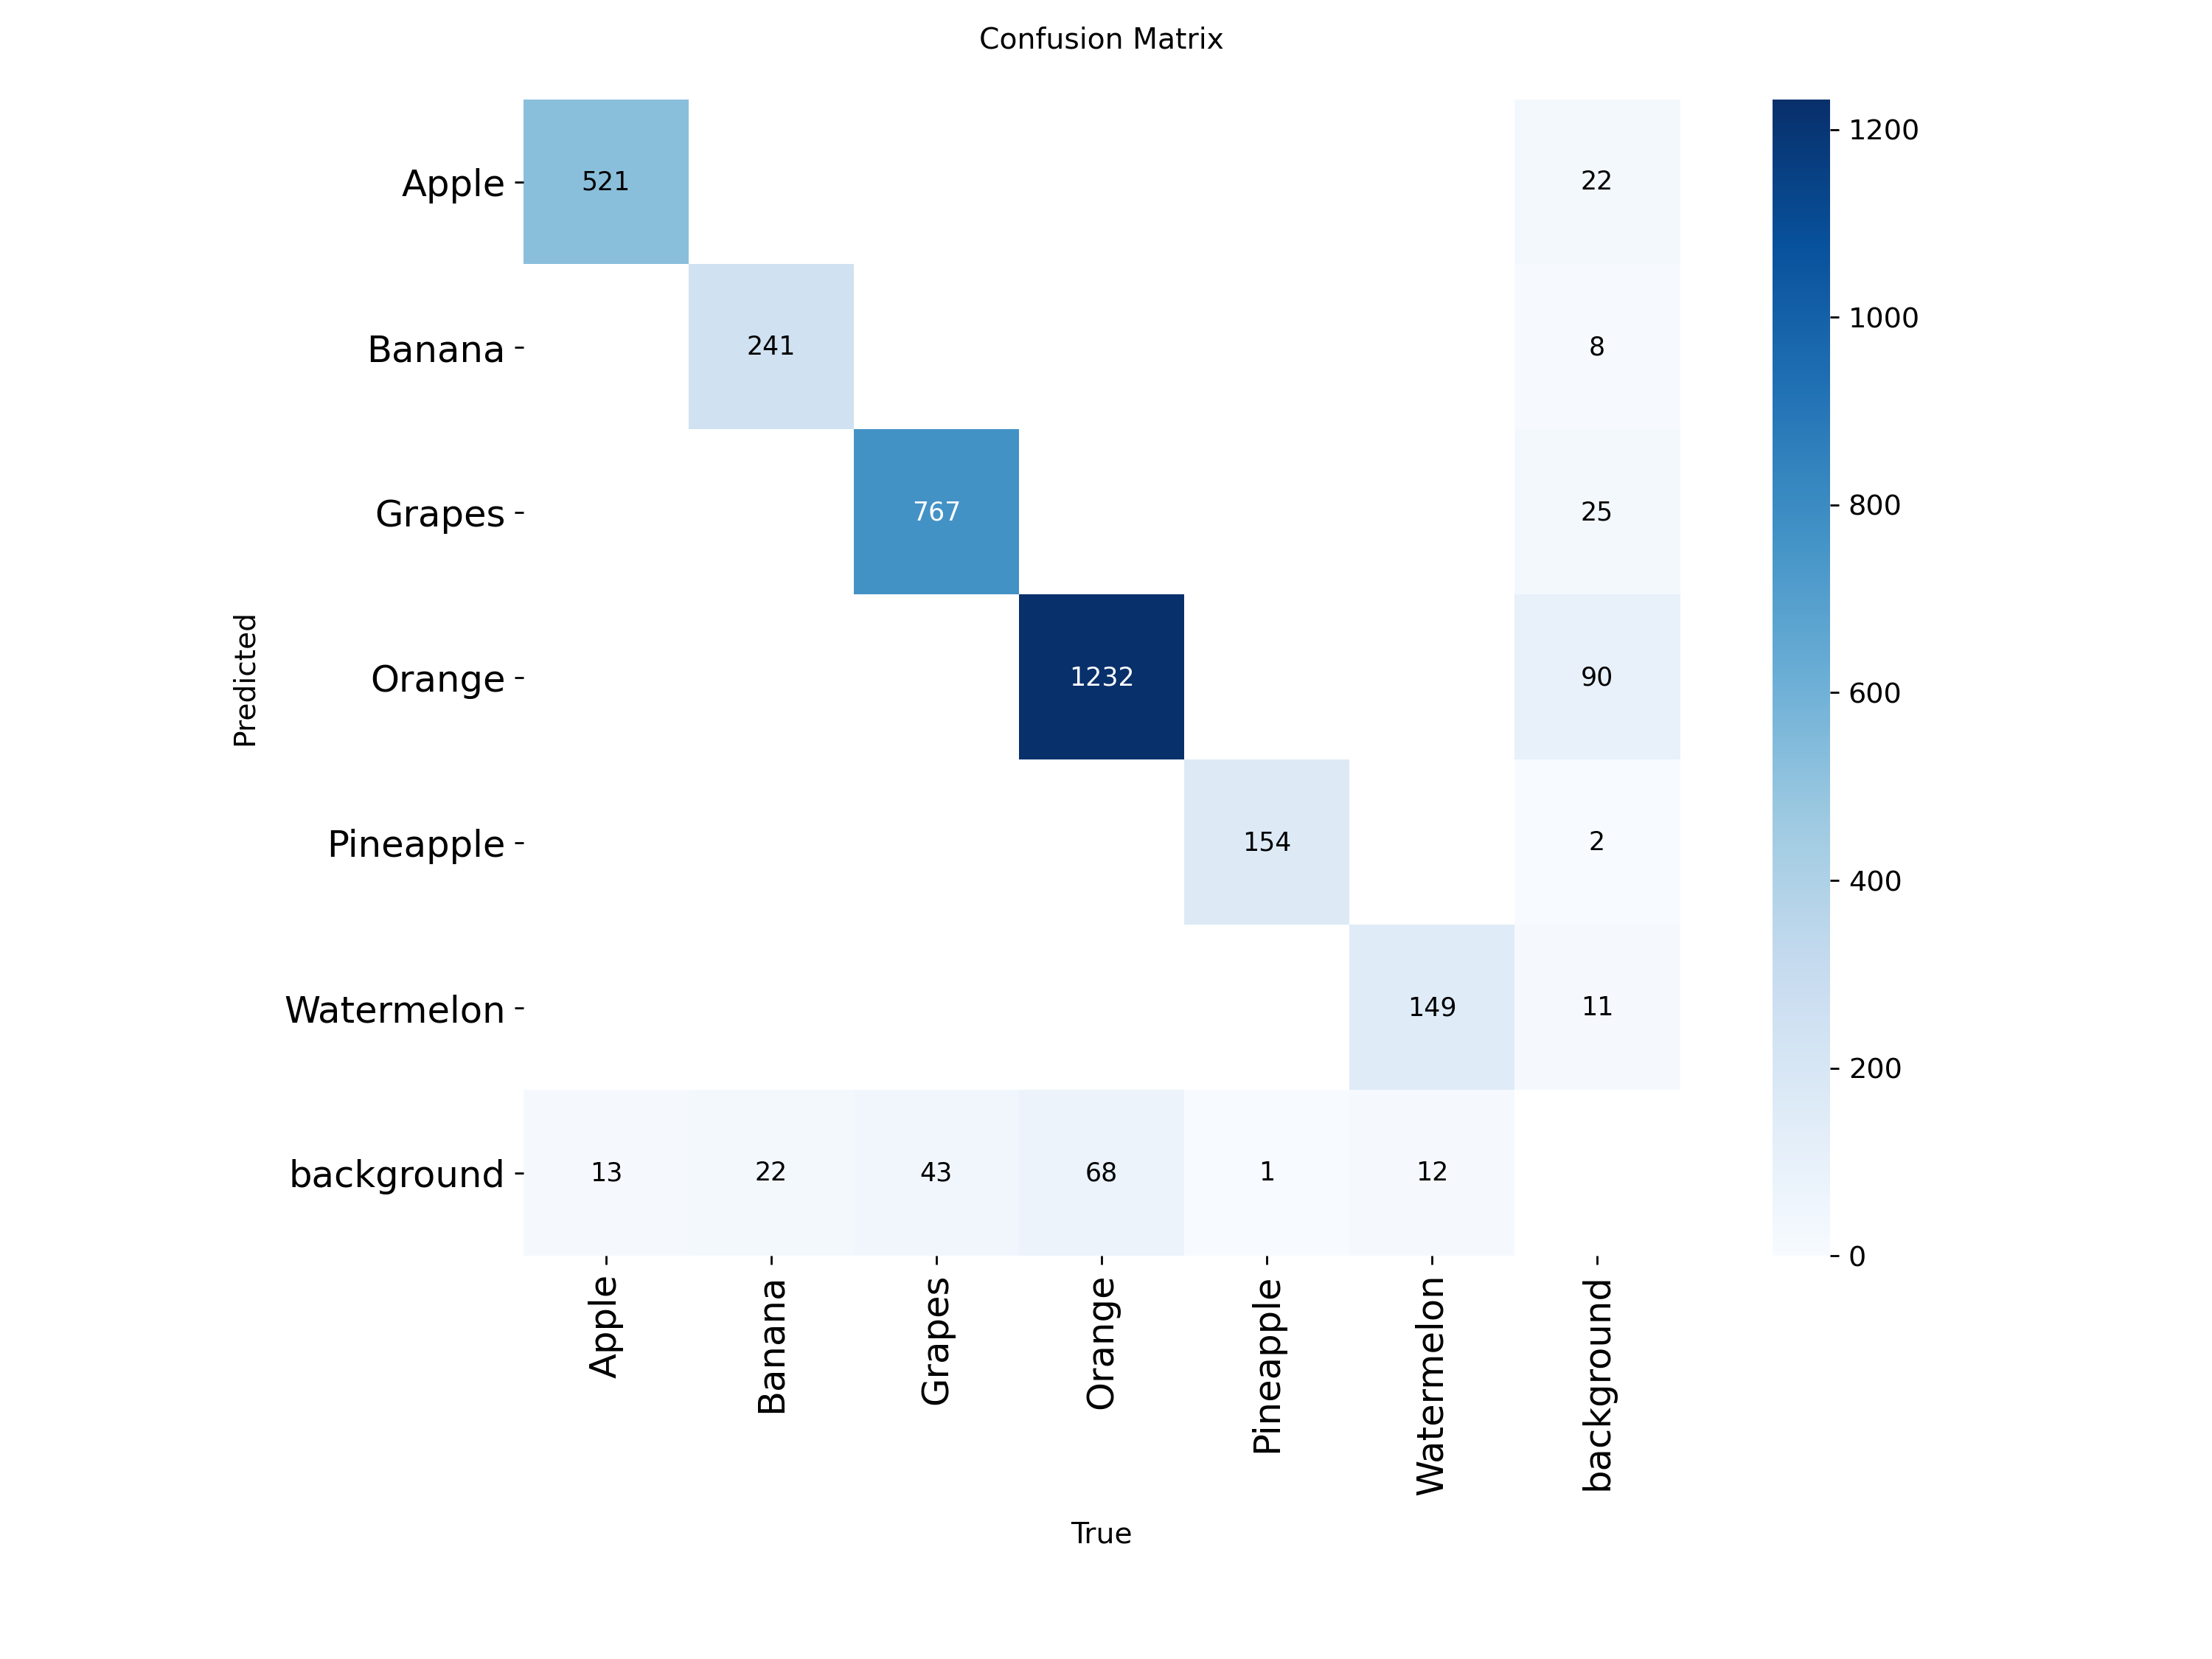


Sample test predictions:
Test Batch 1


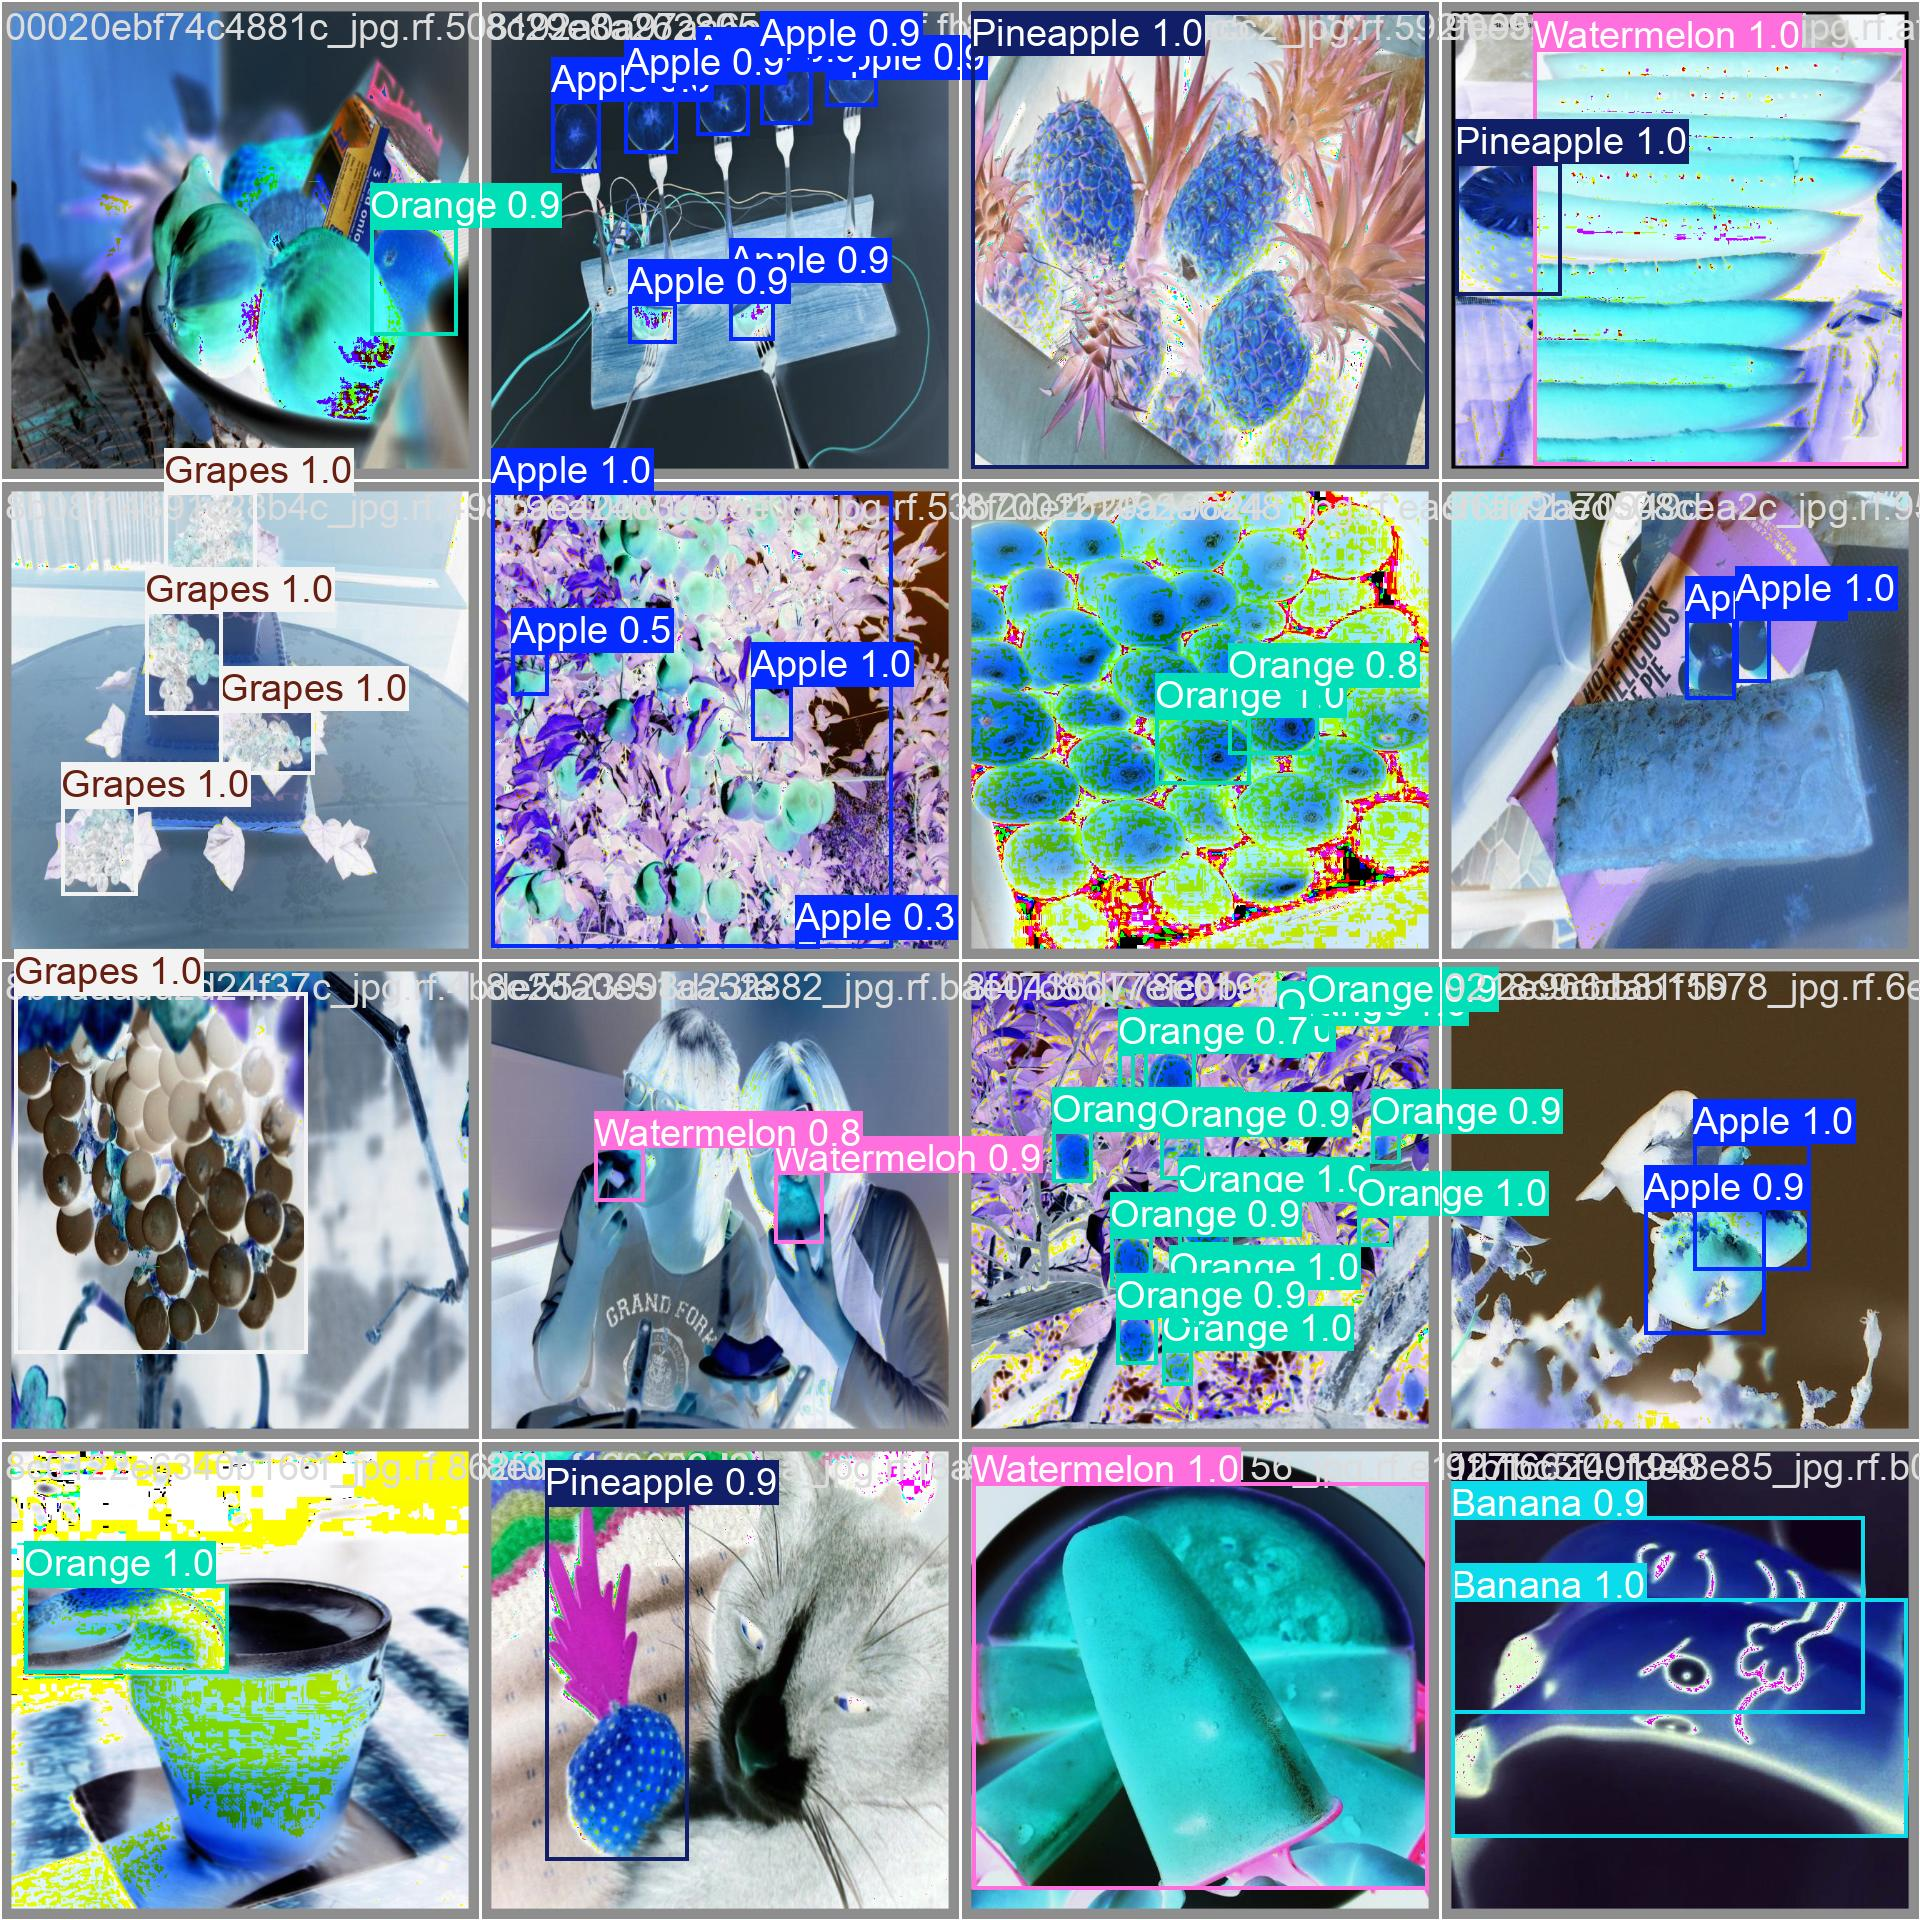

Test Batch 2


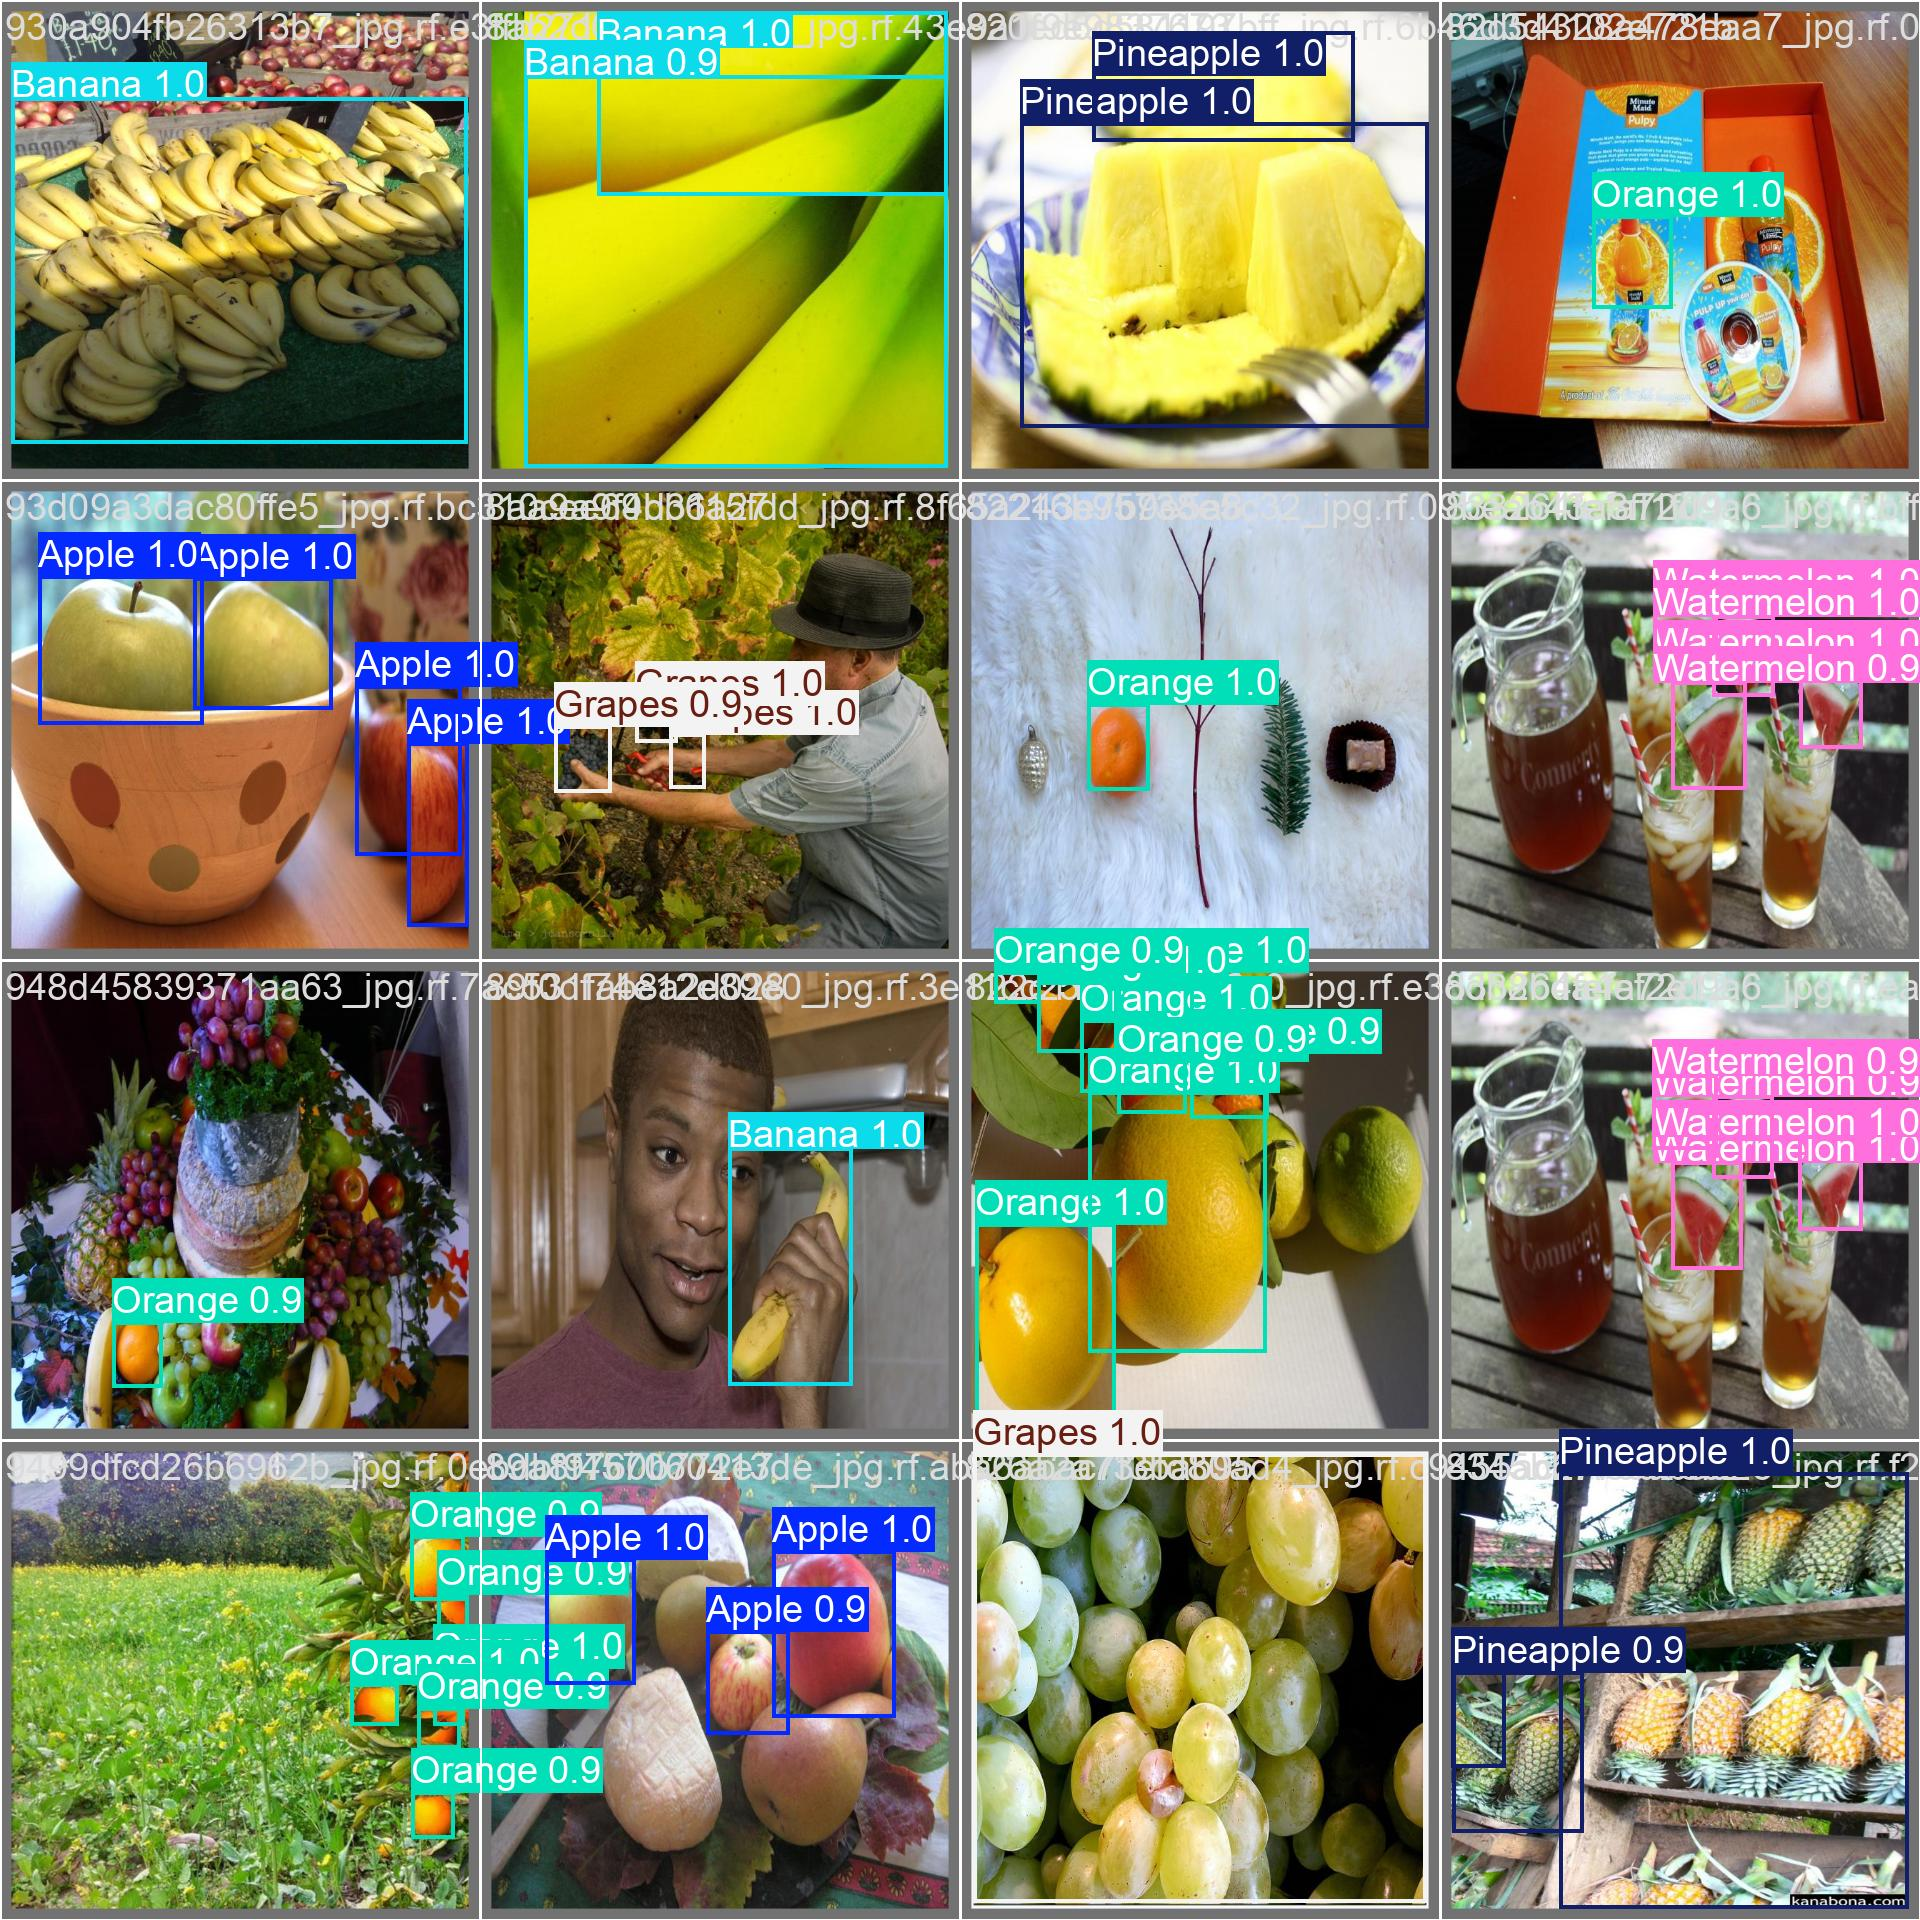

Test Batch 3


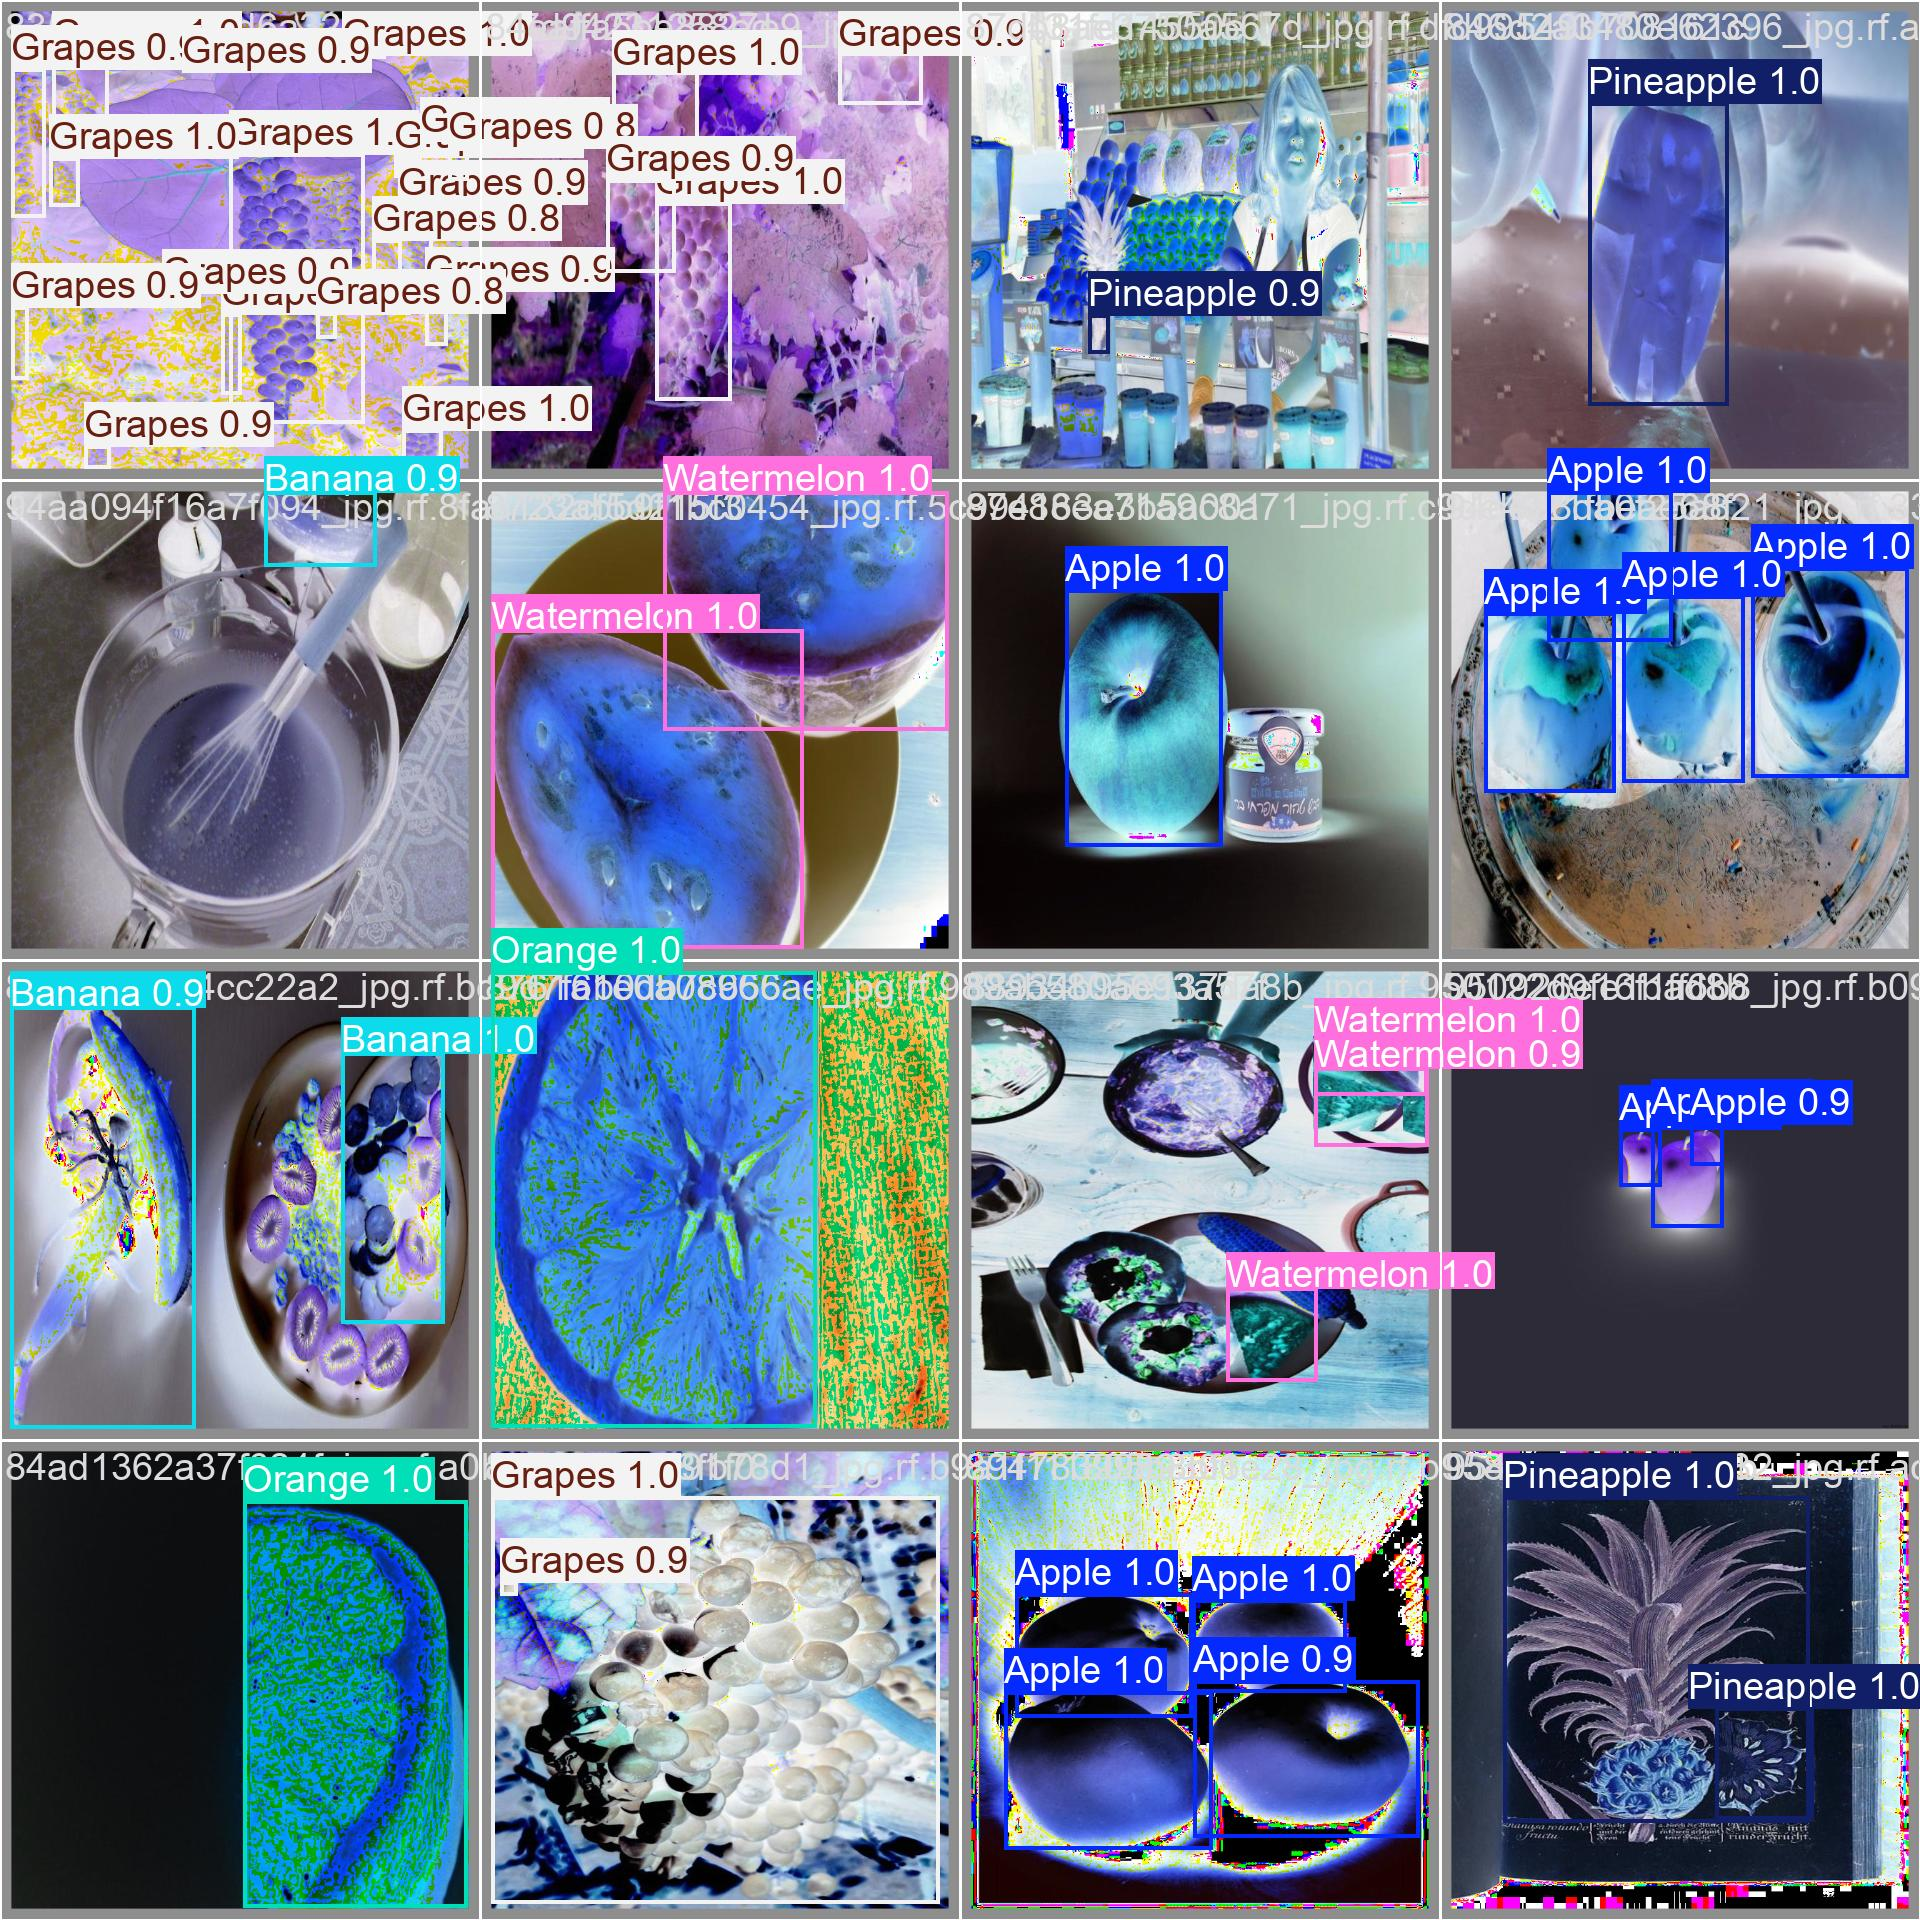

results.csv not found.

[Step 7-8] Running prediction on test set and generating submission.csv...
Predicting on test images in: /kaggle/input/2425-ii-ait-3002-2-object-detection/Dataset/Test/images
Ultralytics 8.3.155 🚀 Python-3.11.11 torch-2.6.0+cu124 


ValueError: Invalid CUDA 'device=0' requested. Use 'device=cpu' or pass valid CUDA device(s) if available, i.e. 'device=0' or 'device=0,1,2,3' for Multi-GPU.

torch.cuda.is_available(): False
torch.cuda.device_count(): 0
os.environ['CUDA_VISIBLE_DEVICES']: None
See https://pytorch.org/get-started/locally/ for up-to-date torch install instructions if no CUDA devices are seen by torch.


In [25]:
trained_model = YOLO("/kaggle/input/yolov11/pytorch/default/1/best.pt")
evaluate_model(trained_model)
predict_and_submission(trained_model)

# RT_DERT 

### Lựa Chọn Mô Hình: RT-DETR-X
*   **Lý do lựa chọn:**
- **Kiến trúc Đột Phá:** Không giống YOLO dựa trên CNN truyền thống, RT-DETR sử dụng kiến trúc **Transformer**. Điều này cho phép mô hình học các mối quan hệ toàn cục (long-range dependencies) và phụ thuộc tầm xa giữa các đối tượng trong ảnh. Phương pháp này có thể hiệu quả hơn trong việc phát hiện các vật thể bị che khuất hoặc trong các cảnh phức tạp với nhiều đối tượng.
- **Hiệu Suất Cân Bằng:** RT-DETR là phiên bản được tối ưu hóa về tốc độ từ dòng mô hình DETR (DEtection TRansformer), khắc phục nhược điểm về tốc độ suy luận của các mô hình DETR đời đầu mà vẫn giữ được độ chính xác cao.
- **Phiên bản `X`:** Tương tự như YOLO, phiên bản `RT-DETR-X` là biến thể lớn nhất và chính xác nhất trong dòng RT-DETR, được chọn để tối đa hóa mAP.

### Tham số huấn luyện – Giữ nguyên để đảm bảo tính nhất quán

Tôi tiếp tục sử dụng lại bộ tham số huấn luyện từ YOLOv11 để dễ dàng so sánh kết quả, đồng thời khai thác tối đa tiềm năng sẵn có từ mô hình.

### Kết quả 

Với cấu hình và mô hình RT-DETR-X, chúng ta thu được kết quả:

*   **mAP:** Đạt **0.83** trên tập test ẩn.

**So sánh với các mô hình YOLO đã thử nghiệm:**
- **Vượt trội so với YOLOv8s (0.73):** RT-DETR-X thể hiện khả năng học đặc trưng và hiệu suất phát hiện tốt hơn đáng kể so với mô hình YOLO cơ bản.
- **Ngang bằng/Hơi nhỉnh hơn so với YOLOv8x và YOLOv9x (đều 0.82):** Mặc dù có kiến trúc rất khác biệt (dựa trên Transformer so với CNN), RT-DETR-X cho thấy hiệu suất **cạnh tranh mạnh mẽ** ngang ngửa với các phiên bản mạnh mẽ nhất của YOLOv8 và YOLOv9 trên tập dữ liệu này. Điều này chứng tỏ hiệu quả của phương pháp DETR được tối ưu.
- **Thấp hơn một chút so với YOLOv11x (0.85):** Kết quả này cho thấy rằng, mặc dù RT-DETR là một công nghệ tiên tiến và mạnh mẽ, YOLOv11x với những cải tiến mới nhất trong dòng YOLO (đặc biệt về backbone, head và các chiến lược huấn luyện) vẫn giữ được ưu thế về mAP trên dataset cụ thể này.

**Lý do giải thích kết quả:**

Kết quả 0.83 mAP đạt được là một thành tích rất tốt, đưa RT-DETR-X vào nhóm các mô hình có hiệu suất cao nhất trong các mô hình em đã thử. Điều này cho thấy rằng mô hình sử dụng kiến trúc Transformer, như RT-DETR-X, hoàn toàn có tiềm năng và khả năng cạnh tranh với các mô hình dựa trên CNN truyền thống, đặc biệt là trong việc học các mối quan hệ phức tạp giữa các vật thể.

Tuy nhiên, so với YOLOv11x (mAP = 0.85), RT-DETR-X vẫn còn thấp hơn một chút. Em nghĩ sự chênh lệch này có thể đến từ một số lý do sau:

- Đặc thù dữ liệu (trái cây): Do trái cây thường có hình dạng và màu sắc tương đối giống nhau, các đặc trưng cục bộ (local features) có thể đóng vai trò quan trọng hơn. Những đặc trưng này thường được học tốt bởi các mô hình CNN như YOLO. Ngoài ra, cách các phép augmentation (như lật hình) ảnh hưởng đến mô hình cũng có thể khác nhau giữa CNN và Transformer.

- Chưa tối ưu hoàn toàn siêu tham số: Em sử dụng các tham số tối ưu chung cho tất cả mô hình. Tuy nhiên, mỗi kiến trúc sẽ có điểm tối ưu riêng, đặc biệt là Transformer thường cần nhiều tinh chỉnh hơn. Nếu tinh chỉnh kỹ hơn cho RT-DETR-X thì có thể hiệu suất sẽ còn tăng thêm.

- YOLOv11 là phiên bản rất mới, tích hợp nhiều cải tiến về backbone, head, cũng như kỹ thuật huấn luyện. Nhờ đó, mô hình này đang tận dụng tối đa sức mạnh của CNN qua nhiều thế hệ tối ưu.

Dù vậy, việc RT-DETR-X đạt được 0.83 mAP vẫn là một kết quả rất đáng tự hào. Nó cho thấy rằng Transformer là một hướng đi đầy tiềm năng trong các bài toán phát hiện đối tượng. Em nghĩ trong tương lai, nếu tiếp tục tối ưu thêm thì RT-DETR-X hoàn toàn có thể vượt qua các phiên bản YOLO mới.

In [ ]:
# #Training Hyperparameters
# EPOCHS = 100
# BATCH_SIZE = 16
# WORKERS = 4
# DEVICE = '0,1' if torch.cuda.is_available() else 'cpu'
# MODEL_NAME = 'rt-dert-x'
# IMG_SIZE = 640
# PROJECT_NAME = 'fruit_detection_exp'
# RUN_NAME = 'run_rt_dert'

# #Optimizer & Scheduler 
# OPTIMIZER = 'AdamW'
# LR0 = 0.0001           
# LRF = 0.005            
# COS_LR = True          
# WEIGHT_DECAY = 0.0005  

# #Training Behavior
# AUGMENT = True        
# PRETRAINED = True     
# PATIENCE = 50         

In [ ]:
# def main():  
#     trained_model = train_model()
#     evaluate_model(trained_model)
#     predict_and_submission(trained_model)
#     print("\nQuá trình hoàn tất!")

# if __name__ == "__main__":
#     main()

# Kết luận

**So sánh tổng quan các kết quả:**

| Mô hình    | mAP           | Nhận xét                                                                        |
| :--------- | :------------ | :------------------------------------------------------------------------------- |
| YOLOv8s    | `0.73`        | Khởi đầu tốt, nhanh, nhẹ, phù hợp cho baseline và thử nghiệm ban đầu.            |
| YOLOv8x    | `0.82`        | **Cải thiện đáng kể**, mạnh mẽ và ổn định, lý tưởng cho mAP cao.                 |
| YOLOv9x    | `0.82`        | **Ngang bằng** với YOLOv8x trên tập dữ liệu này, cho thấy hiệu quả tương đương.   |
| RT-DETR-X  | **`0.83`**    | **Vượt trội** so với YOLOv8x/YOLOv9x, thể hiện sức mạnh của kiến trúc Transformer. |
| **YOLOv11x** | **`0.85`**    | **Đạt mAP cao nhất**.             |

**Kết luận**
- Các phiên bản YOLO x (extra large) như YOLOv8x, YOLOv9x hay YOLOv11x cho thấy hiệu suất vượt trội rõ rệt so với các bản nhỏ như YOLOv8s. Điều này chứng minh rằng khi mô hình đủ lớn (nhiều tham số, backbone mạnh hơn), nó sẽ có khả năng học được nhiều đặc trưng hơn và tổng quát hóa tốt hơn.
- Việc bật AUGMENT=True khi huấn luyện giúp mô hình học tốt các biến thể ảnh (như lật ngang) và tổng quát hóa tốt hơn.
- Optimizer và Scheduler: AdamW và Cosine LR giúp các mô hình lớn học ổn định và hiệu quả.
- Thử nghiệm với các kiến trúc khác như RT-DETR là rất đáng giá, dù không phải lúc nào cũng là cao nhất, nhưng nó mở rộng hiểu biết về các phương pháp khác nhau và tiềm năng của chúng.
